# 02 — Building Passing Networks

**Goal:** Build one directed weighted passing network for every team in every match.

The 2022 World Cup has 64 matches × 2 teams = **up to 128 team-match networks**.

**Network definition:**
- One graph per `(match_id, team)`
- **Nodes** = players
- **Directed edges** = completed passes from passer → recipient
- **Edge weight** = number of completed passes between that pair

**Outputs:**
- `data/processed/pass_network_edges.csv` — edge list with weights
- `data/processed/pass_network_nodes.csv` — node table with pass stats

In [ ]:
import sys
sys.path.insert(0, '../src')

from pathlib import Path
import pandas as pd
import networkx as nx

from data_loader import load_matches, load_events

DATA_DIR = Path('../data')
RAW_DIR  = DATA_DIR / 'raw'
PROC_DIR = DATA_DIR / 'processed'
PROC_DIR.mkdir(parents=True, exist_ok=True)

matches, _ = load_matches(cache_path=RAW_DIR / 'matches.csv')

## 1. Load all completed passes

Loop over all 64 matches, filter to completed passes, and concatenate into one DataFrame.

- **Completed** = `pass_outcome` is NaN (StatsBomb convention)
- Drop rows where `player` or `pass_recipient` is missing

In [3]:
all_pass_rows = []

for _, match_row in matches.iterrows():
    mid    = int(match_row['match_id'])
    events = load_events(mid, cache_dir=RAW_DIR / 'events')

    # Step 1: keep only Pass events
    passes = events[events['type'] == 'Pass'].copy()

    # Step 2: keep only completed passes (pass_outcome NaN = success)
    passes = passes[passes['pass_outcome'].isna()]

    # Step 3: keep only the columns needed for networks
    passes = passes[['match_id', 'team', 'player', 'pass_recipient']]

    # Step 4: drop rows where passer or recipient is unknown
    passes = passes.dropna(subset=['player', 'pass_recipient'])

    all_pass_rows.append(passes)

# Combine all matches into one DataFrame
pass_df = pd.concat(all_pass_rows, ignore_index=True)

print(f"Total completed passes loaded : {len(pass_df):,}")
print(f"Matches covered               : {pass_df['match_id'].nunique()}")
print(f"Teams covered                 : {pass_df['team'].nunique()}")
print(f"\nSample rows:")
pass_df.head(6)

Total completed passes loaded : 56,346
Matches covered               : 64
Teams covered                 : 32

Sample rows:


,match_id,team,player,pass_recipient
0,3857276,Morocco,Youssef En-Nesyri,Sofyan Amrabat
1,3857276,Morocco,Sofyan Amrabat,Nayef Aguerd
2,3857276,Morocco,Nayef Aguerd,Romain Saïss
3,3857276,Morocco,Romain Saïss,Nayef Aguerd
4,3857276,Morocco,Nayef Aguerd,Achraf Hakimi Mouh
5,3857276,Morocco,Achraf Hakimi Mouh,Sofyan Amrabat


## 2. Build passing networks

Group passes by `(match_id, team)` and build one `DiGraph` per group.

- Count how many times each passer → recipient pair appears — that becomes the **edge weight**
- Store all graphs in a dictionary: `key = (match_id, team)`, `value = nx.DiGraph`

In [4]:
networks = {}

for (match_id, team), group in pass_df.groupby(['match_id', 'team']):

    G = nx.DiGraph()

    # Count completed passes between each passer-recipient pair
    edge_counts = (
        group.groupby(['player', 'pass_recipient'])
             .size()
             .reset_index(name='weight')
    )

    # Add each pair as a directed edge with its pass count as the weight
    for _, row in edge_counts.iterrows():
        G.add_edge(row['player'], row['pass_recipient'], weight=int(row['weight']))

    networks[(match_id, team)] = G

print(f"Networks built: {len(networks)}  (expected ~128 = 64 matches × 2 teams)")

# Quick look at one network
sample_key = list(networks.keys())[0]
sample_G   = networks[sample_key]
print(f"\nExample — {sample_key}")
print(f"  Players (nodes) : {sample_G.number_of_nodes()}")
print(f"  Pass pairs (edges): {sample_G.number_of_edges()}")
print(f"  Top 5 edges by weight:")
top_edges = sorted(sample_G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:5]
for src, dst, data in top_edges:
    print(f"    {src} → {dst}  ({data['weight']} passes)")

Networks built: 128  (expected ~128 = 64 matches × 2 teams)

Example — (np.int64(3857254), 'Denmark')
  Players (nodes) : 15
  Pass pairs (edges): 124
  Top 5 edges by weight:
    Christian Dannemann Eriksen → Pierre-Emile Højbjerg  (16 passes)
    Rasmus Nissen Kristensen → Andreas Skov Olsen  (16 passes)
    Andreas Christensen → Simon Thorup Kjær  (15 passes)
    Joachim Andersen → Andreas Christensen  (15 passes)
    Pierre-Emile Højbjerg → Christian Dannemann Eriksen  (14 passes)


## 3. Build the edge list table

One row per passer → recipient pair per team-match.

In [5]:
edge_rows = []

for (match_id, team), G in networks.items():
    for passer, recipient, data in G.edges(data=True):
        edge_rows.append({
            'match_id':  match_id,
            'team':      team,
            'passer':    passer,
            'recipient': recipient,
            'weight':    data['weight'],
        })

edges_df = pd.DataFrame(edge_rows)

print(f"Edge list shape: {edges_df.shape}")
edges_df.head(8)

Edge list shape: (15206, 5)


,match_id,team,passer,recipient,weight
0,3857254,Denmark,Andreas Christensen,Christian Dannemann Eriksen,10
1,3857254,Denmark,Andreas Christensen,Joachim Andersen,9
2,3857254,Denmark,Andreas Christensen,Joakim Mæhle,9
3,3857254,Denmark,Andreas Christensen,Kasper Dolberg,1
4,3857254,Denmark,Andreas Christensen,Kasper Schmeichel,3
5,3857254,Denmark,Andreas Christensen,Mathias Jensen,11
6,3857254,Denmark,Andreas Christensen,Mikkel Damsgaard,2
7,3857254,Denmark,Andreas Christensen,Pierre-Emile Højbjerg,11


## 4. Build the node table

One row per player per team-match.

- `total_passes_sent`     = how many completed passes this player made (weighted out-degree)
- `total_passes_received` = how many completed passes this player received (weighted in-degree)
- `weighted_degree`       = total involvement = sent + received

In [6]:
node_rows = []

for (match_id, team), G in networks.items():
    out_deg = dict(G.out_degree(weight='weight'))   # passes sent
    in_deg  = dict(G.in_degree(weight='weight'))    # passes received

    for player in G.nodes:
        sent     = out_deg.get(player, 0)
        received = in_deg.get(player, 0)
        node_rows.append({
            'match_id':              match_id,
            'team':                  team,
            'player':                player,
            'total_passes_sent':     sent,
            'total_passes_received': received,
            'weighted_degree':       sent + received,
        })

nodes_df = pd.DataFrame(node_rows)

print(f"Node table shape: {nodes_df.shape}")
nodes_df.head(8)

Node table shape: (1978, 6)


,match_id,team,player,total_passes_sent,total_passes_received,weighted_degree
0,3857254,Denmark,Andreas Christensen,78,73,151
1,3857254,Denmark,Christian Dannemann Eriksen,66,67,133
2,3857254,Denmark,Joachim Andersen,62,58,120
3,3857254,Denmark,Joakim Mæhle,43,40,83
4,3857254,Denmark,Kasper Dolberg,10,16,26
5,3857254,Denmark,Kasper Schmeichel,22,13,35
6,3857254,Denmark,Mathias Jensen,28,29,57
7,3857254,Denmark,Mikkel Damsgaard,22,23,45


## 5. Save outputs

In [7]:
edges_df.to_csv(PROC_DIR / 'pass_network_edges.csv', index=False)
nodes_df.to_csv(PROC_DIR / 'pass_network_nodes.csv', index=False)

print("Saved:")
print(f"  data/processed/pass_network_edges.csv  ({len(edges_df):,} rows)")
print(f"  data/processed/pass_network_nodes.csv  ({len(nodes_df):,} rows)")

Saved:
  data/processed/pass_network_edges.csv  (15,206 rows)
  data/processed/pass_network_nodes.csv  (1,978 rows)


## 6. Summary statistics

In [8]:
players_per_net = [G.number_of_nodes() for G in networks.values()]
edges_per_net   = [G.number_of_edges() for G in networks.values()]
passes_per_net  = pass_df.groupby(['match_id', 'team']).size().values

print("=" * 40)
print("Network build summary")
print("=" * 40)
print(f"Matches                        : {pass_df['match_id'].nunique()}")
print(f"Teams                          : {pass_df['team'].nunique()}")
print(f"Team-match networks created    : {len(networks)}")
print(f"Avg players per network        : {sum(players_per_net) / len(players_per_net):.1f}")
print(f"Avg edges per network          : {sum(edges_per_net)   / len(edges_per_net):.1f}")
print(f"Avg completed passes per network: {passes_per_net.mean():.1f}")
print("=" * 40)

Network build summary
Matches                        : 64
Teams                          : 32
Team-match networks created    : 128
Avg players per network        : 15.5
Avg edges per network          : 118.8
Avg completed passes per network: 440.2


## 7. Visualise passing networks

Draw the networks on a pitch.
- **Node position** = player's average pass-start location across the match
- **Node size** ∝ total passes made
- **Edge width & opacity** ∝ pass count between that pair
- Only edges with ≥ 3 passes are shown to keep it readable

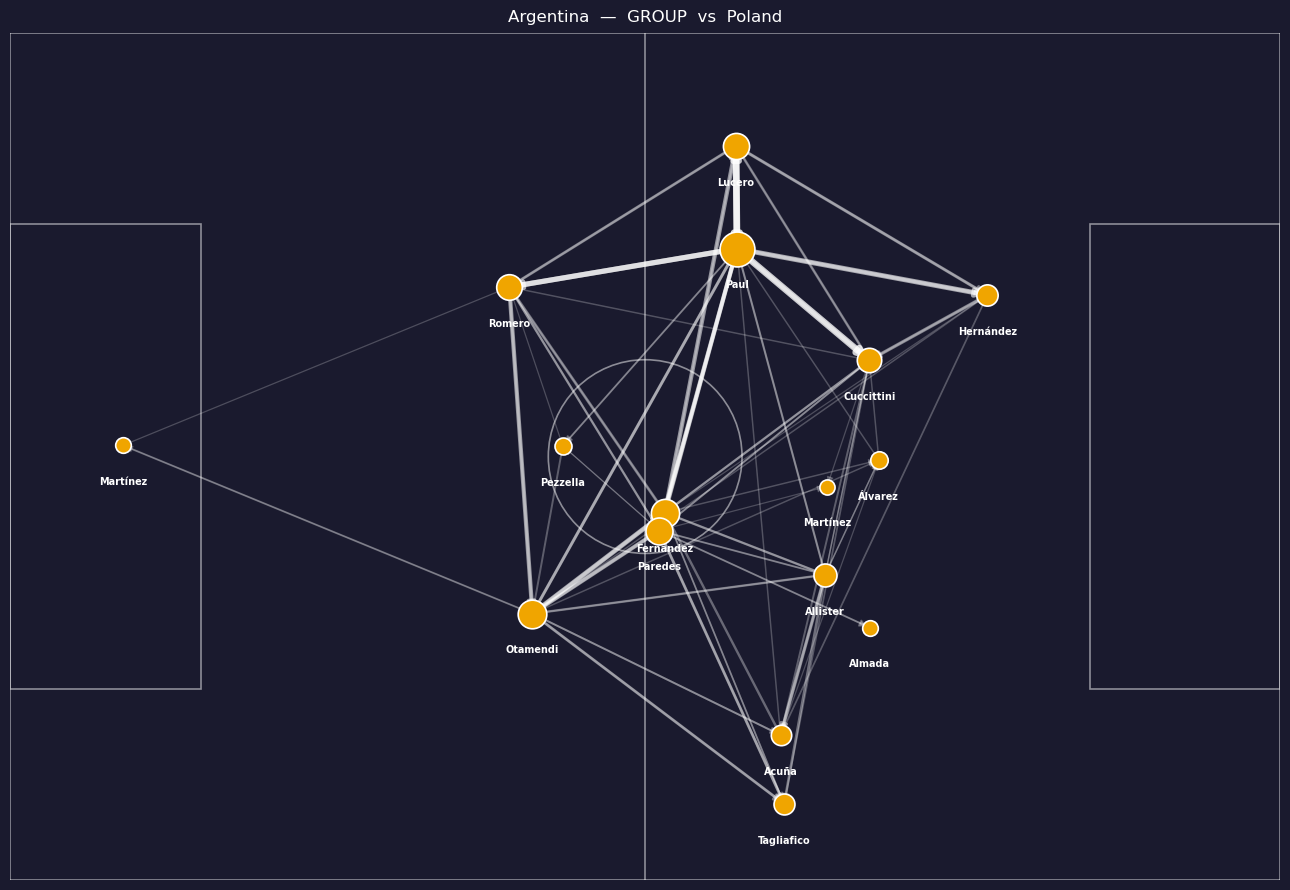

Saved: outputs/figures/02_network_argentina.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np

FIG_DIR = Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)


def draw_pitch(ax, bg='#1a1a2e', line_color='white'):
    """Minimal football pitch on a matplotlib axes."""
    ax.set_facecolor(bg)
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 80)
    lw = 1.2
    for x in [0, 60, 120]:
        ax.axvline(x, color=line_color, lw=lw, alpha=0.5)
    for y in [0, 80]:
        ax.axhline(y, color=line_color, lw=lw, alpha=0.5)
    ax.add_patch(plt.Rectangle((0, 18), 18, 44, fill=False,
                                edgecolor=line_color, lw=lw, alpha=0.5))
    ax.add_patch(plt.Rectangle((102, 18), 18, 44, fill=False,
                                edgecolor=line_color, lw=lw, alpha=0.5))
    ax.add_patch(plt.Circle((60, 40), 9.15, fill=False,
                             color=line_color, lw=lw, alpha=0.5))
    ax.set_aspect('equal')
    ax.axis('off')


def plot_network_on_pitch(match_id, team, networks, events_cache_dir,
                          min_edge_weight=3, title=None, ax=None):
    """
    Draw a passing network overlaid on a pitch.
      - Node position = player's average pass-start location
      - Node size     ∝ passes made (weighted out-degree)
      - Edge width    ∝ pass count between that pair
      - Arrows show direction of play
    """
    # Load events to get x, y coordinates for this team
    ev     = load_events(match_id, cache_dir=events_cache_dir)
    passes = ev[
        (ev['type'] == 'Pass') &
        (ev['pass_outcome'].isna()) &
        (ev['team'] == team)
    ].copy()

    # Extract coordinates (works for both lists and numpy arrays from parquet)
    def _c(v, i):
        try:    return float(v[i])
        except: return None

    passes['x'] = passes['location'].apply(lambda v: _c(v, 0))
    passes['y'] = passes['location'].apply(lambda v: _c(v, 1))

    # Average pitch position per player
    avg_pos = (
        passes.dropna(subset=['x', 'y'])
              .groupby('player')[['x', 'y']]
              .mean()
    )

    G       = networks[(match_id, team)]
    out_deg = dict(G.out_degree(weight='weight'))
    max_w   = max((d['weight'] for *_, d in G.edges(data=True)), default=1)
    max_d   = max(out_deg.values(), default=1)

    if ax is None:
        _, ax = plt.subplots(figsize=(14, 9))

    draw_pitch(ax)

    pos = {p: (r['x'], r['y']) for p, r in avg_pos.iterrows() if p in G.nodes}

    # Draw edges
    for src, dst, data in G.edges(data=True):
        if data['weight'] < min_edge_weight or src not in pos or dst not in pos:
            continue
        x1, y1 = pos[src]
        x2, y2 = pos[dst]
        alpha = 0.15 + 0.65 * (data['weight'] / max_w)
        lw    = 0.4 + 4.5  * (data['weight'] / max_w)
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='-|>', color='white',
                                   lw=lw, alpha=alpha),
                    zorder=3)

    # Draw nodes
    for player, (x, y) in pos.items():
        size = 80 + 550 * (out_deg.get(player, 0) / max_d)
        ax.scatter(x, y, s=size, c='#f0a500', edgecolors='white',
                   linewidths=1.2, zorder=5)
        ax.text(x, y - 3, player.split()[-1], color='white',
                fontsize=7, ha='center', va='top',
                fontweight='bold', zorder=6)

    ax.set_title(title or team, color='white', fontsize=12, pad=8)


# Draw one example: Argentina's first match
arg_key    = [(mid, t) for mid, t in networks if t == 'Argentina'][0]
match_id, team = arg_key
match_info = matches[matches['match_id'] == match_id].iloc[0]
opponent   = match_info['away_team'] if match_info['home_team'] == team else match_info['home_team']
stage      = match_info['stage_label'].upper()

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#1a1a2e')
plot_network_on_pitch(match_id, team, networks, RAW_DIR / 'events',
                      min_edge_weight=3,
                      title=f"{team}  —  {stage}  vs  {opponent}",
                      ax=ax)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_network_argentina.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Saved: outputs/figures/02_network_argentina.png")

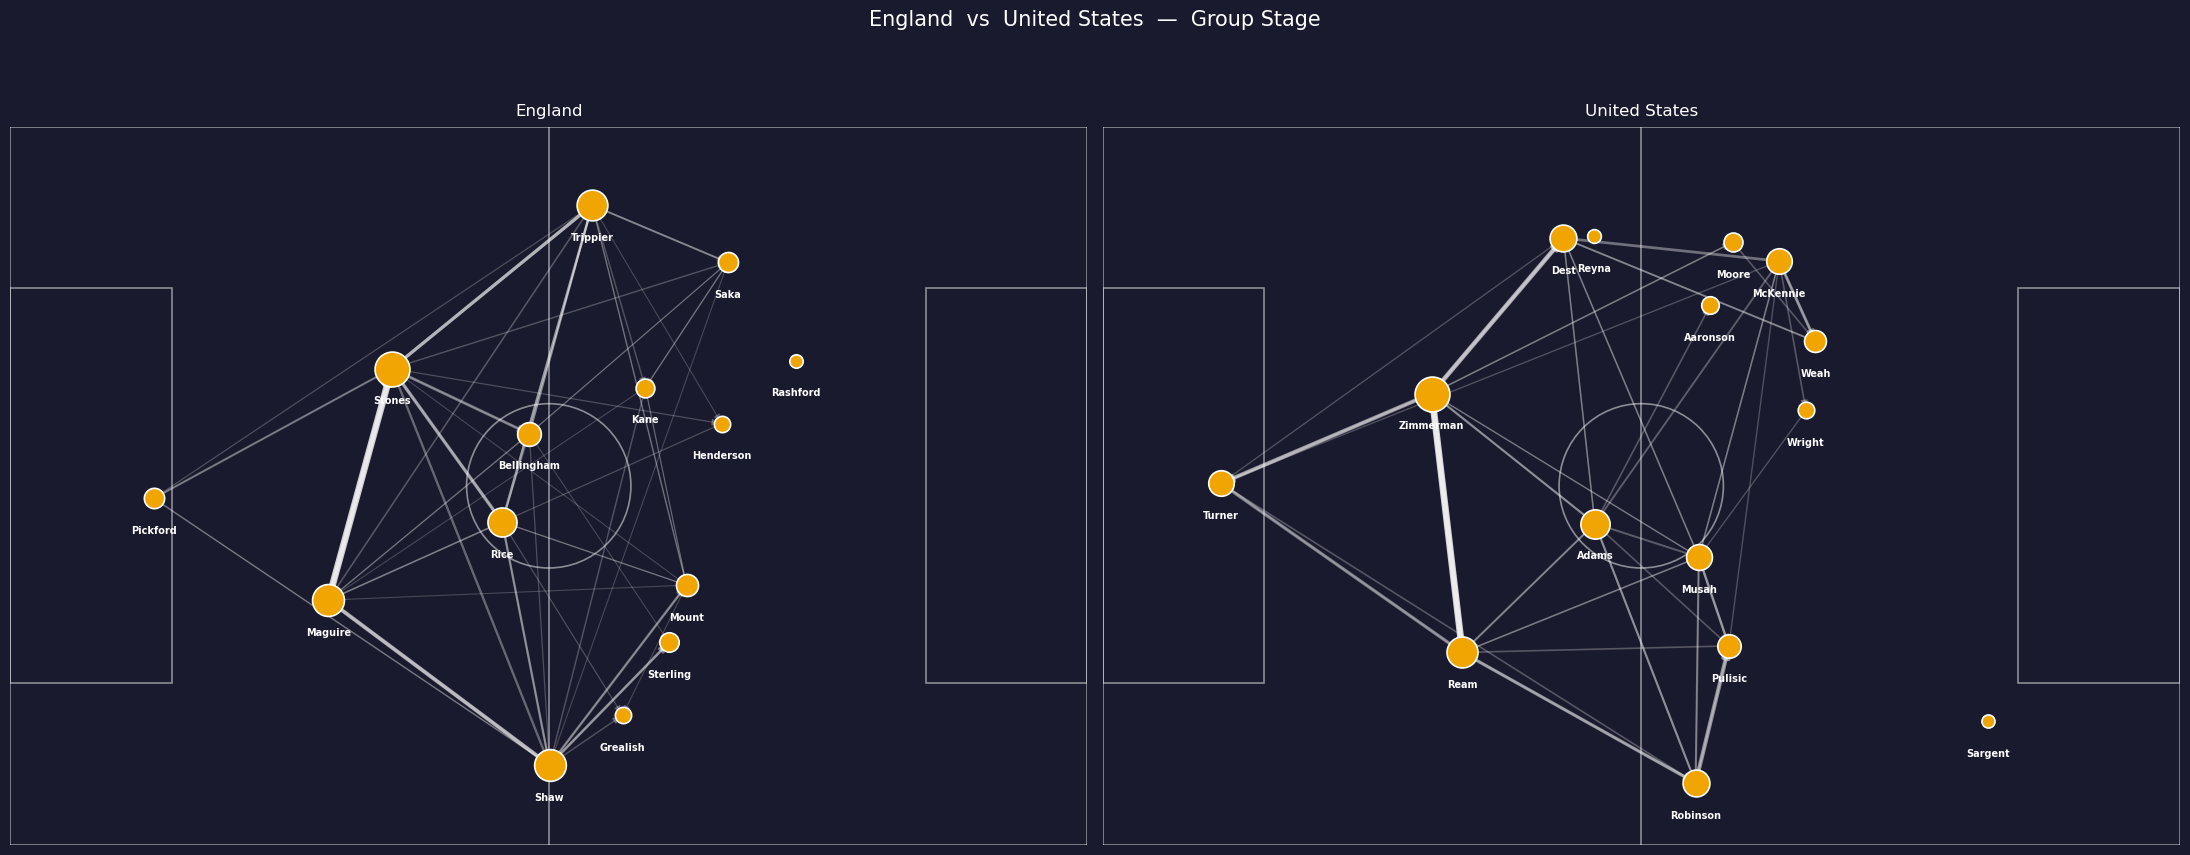

Saved: outputs/figures/02_network_comparison.png


In [10]:
# Side-by-side: both teams from one match
group_match_id = int(matches[matches['stage_label'] == 'group']['match_id'].iloc[5])
home = matches[matches['match_id'] == group_match_id]['home_team'].values[0]
away = matches[matches['match_id'] == group_match_id]['away_team'].values[0]

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.patch.set_facecolor('#1a1a2e')

for ax, team in zip(axes, [home, away]):
    plot_network_on_pitch(
        group_match_id, team, networks,
        RAW_DIR / 'events', min_edge_weight=3,
        title=team, ax=ax,
    )

fig.suptitle(f'{home}  vs  {away}  —  Group Stage',
             color='white', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_network_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print(f"Saved: outputs/figures/02_network_comparison.png")

## 8. Interactive web app

Build a self-contained `index.html` that lets you browse all 64 matches and view both teams' passing networks side by side. No server required — just open the file in your browser.

In [11]:
import json

WEB_DIR = Path('../outputs/web')
WEB_DIR.mkdir(parents=True, exist_ok=True)

STAGE_ORDER = {
    'group': 1, 'R16': 2, 'QF': 3, 'SF': 4,
    'Final': 5, '3rd Place Final': 6,
}
SET_PIECE_TYPES = {'Corner', 'Free Kick', 'Throw-in', 'Kick Off', 'Goal Kick'}

def _c(v, i):
    try: return float(v[i])
    except: return None

def _pt_name(v):
    """Extract name string from StatsBomb pass_type (dict, str, or NaN)."""
    if v is None: return ''
    try:
        if pd.isna(v): return ''
    except Exception: pass
    if isinstance(v, dict): return v.get('name', '')
    return str(v)

def build_net(ev, team):
    """Build enriched node / edge / metrics bundle for one team-match."""
    tp = ev[
        (ev['type'] == 'Pass') &
        (ev['pass_outcome'].isna()) &
        (ev['team'] == team)
    ].copy()

    # Passer location
    tp['x'] = tp['location'].apply(lambda v: _c(v, 0))
    tp['y'] = tp['location'].apply(lambda v: _c(v, 1))

    # End location → progressive / final-third flags
    has_end = 'pass_end_location' in tp.columns
    if has_end:
        tp['ex']      = tp['pass_end_location'].apply(lambda v: _c(v, 0))
        tp['is_prog'] = (tp['ex'] - tp['x']) >= 10
        tp['is_ft']   = (tp['x'] < 80) & (tp['ex'] >= 80)
    else:
        tp['is_prog'] = False
        tp['is_ft']   = False

    # Half flag (minute ≤ 45 = first half)
    tp['half'] = tp['minute'].apply(
        lambda m: 1 if pd.notna(m) and float(m) <= 45 else 2
    )

    # Open-play flag (no set-piece type)
    has_pt = 'pass_type' in tp.columns
    if has_pt:
        tp['is_op'] = ~tp['pass_type'].apply(_pt_name).isin(SET_PIECE_TYPES)
    else:
        tp['is_op'] = True

    completed = tp.dropna(subset=['player', 'pass_recipient'])

    # Average pitch position per player (from passer start locations)
    avg_pos = tp.dropna(subset=['x', 'y']).groupby('player')[['x', 'y']].mean()
    sent_ct = completed.groupby('player').size()
    recv_ct = completed.groupby('pass_recipient').size()

    # Involvement rank (sent + received, 1 = most involved)
    inv = {p: int(sent_ct.get(p, 0)) + int(recv_ct.get(p, 0)) for p in avg_pos.index}
    ranked   = sorted(inv.items(), key=lambda kv: -kv[1])
    rank_map = {p: i + 1 for i, (p, _) in enumerate(ranked)}

    nodes = [
        {'id': p,
         'x':    round(float(r['x']), 1),
         'y':    round(float(r['y']), 1),
         'sent': int(sent_ct.get(p, 0)),
         'recv': int(recv_ct.get(p, 0)),
         'rank': rank_map.get(p, 999)}
        for p, r in avg_pos.iterrows()
    ]

    # Edge aggregation with per-filter breakdowns
    edges = []
    for (passer, recip), grp in completed.groupby(['player', 'pass_recipient']):
        e = {
            's': passer, 't': recip, 'w': len(grp),
            'h1': int((grp['half'] == 1).sum()),
            'h2': int((grp['half'] == 2).sum()),
        }
        if has_end:
            e['prog'] = int(grp['is_prog'].sum())
            e['ft']   = int(grp['is_ft'].sum())
        if has_pt:
            e['op'] = int(grp['is_op'].sum())
        edges.append(e)

    # Pre-compute team-level metrics for the stats cards
    n_nodes, n_edges = len(nodes), len(edges)
    total    = len(completed)
    max_poss = n_nodes * (n_nodes - 1) if n_nodes > 1 else 1
    density  = round(n_edges / max_poss, 4) if max_poss else 0
    most_inv = ranked[0][0] if ranked else ''
    most_tot = ranked[0][1] if ranked else 0
    total_inv = sum(inv.values())
    top_rel  = round(most_tot / total_inv, 3) if total_inv else 0
    top_e    = max(edges, key=lambda e: e['w']) if edges else None
    top_pair = (f"{top_e['s'].split()[-1]} → {top_e['t'].split()[-1]}") if top_e else ''

    metrics = {
        'completed_passes':    total,
        'unique_pairs':        n_edges,
        'num_players':         n_nodes,
        'density':             density,
        'most_involved':       most_inv,
        'most_involved_total': most_tot,
        'top_reliance':        top_rel,
        'top_pair':            top_pair,
        'top_pair_full':       f"{top_e['s']} → {top_e['t']}" if top_e else '',
        'top_pair_count':      top_e['w'] if top_e else 0,
        'total_prog': sum(e.get('prog', 0) for e in edges) if has_end else None,
        'total_ft':   sum(e.get('ft',   0) for e in edges) if has_end else None,
    }

    return {'metrics': metrics, 'nodes': nodes, 'edges': edges}

# Build sorted match list
match_list = []
for _, row in matches.iterrows():
    sl = str(row.get('stage_label', ''))
    match_list.append({
        'match_id':   int(row['match_id']),
        'home_team':  str(row['home_team']),
        'away_team':  str(row['away_team']),
        'home_score': int(row['home_score']),
        'away_score': int(row['away_score']),
        'stage':      sl,
        'stage_ord':  STAGE_ORDER.get(sl, 99),
        'date':       str(row['match_date']),
    })
match_list.sort(key=lambda m: (m['stage_ord'], m['date']))

# Build all 128 networks
net_data = {}
for _, row in matches.iterrows():
    mid = int(row['match_id'])
    ev  = load_events(mid, cache_dir=RAW_DIR / 'events')
    for team in [str(row['home_team']), str(row['away_team'])]:
        net_data[f'{mid}_{team}'] = build_net(ev, team)

payload = json.dumps({'matches': match_list, 'networks': net_data}, ensure_ascii=False)

sample = next(iter(net_data.values()))
print(f"Ready: {len(match_list)} matches · {len(net_data)} networks · {len(payload)//1024} KB")
print(f"Sample metrics : {sample['metrics']}")
print(f"Node keys      : {list(sample['nodes'][0].keys())}")
print(f"Edge keys      : {list(sample['edges'][0].keys())}")

Ready: 64 matches · 128 networks · 1873 KB
Sample metrics : {'completed_passes': 480, 'unique_pairs': 140, 'num_players': 16, 'density': 0.5833, 'most_involved': 'Kamal Miller', 'most_involved_total': 159, 'top_reliance': 0.166, 'top_pair': 'Vitoria → Miller', 'top_pair_full': 'Steven de Sousa Vitoria → Kamal Miller', 'top_pair_count': 20, 'total_prog': 128, 'total_ft': 43}
Node keys      : ['id', 'x', 'y', 'sent', 'recv', 'rank']
Edge keys      : ['s', 't', 'w', 'h1', 'h2', 'prog', 'ft', 'op']


In [12]:
HTML_TEMPLATE = r"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>WC 2022 — Passing Networks</title>
<style>
*,*::before,*::after{box-sizing:border-box;margin:0;padding:0}
body{background:#0d1117;color:#e6edf3;font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;display:flex;height:100vh;overflow:hidden}

/* ── Sidebar ─────────────────────────────────────── */
#sidebar{width:255px;flex-shrink:0;background:#161b22;border-right:1px solid #30363d;display:flex;flex-direction:column;overflow:hidden}
#sidebar-title{padding:13px 16px;font-size:13px;font-weight:700;color:#f0a500;border-bottom:1px solid #30363d}
#match-list{overflow-y:auto;flex:1}
#match-list::-webkit-scrollbar{width:4px}
#match-list::-webkit-scrollbar-thumb{background:#30363d;border-radius:2px}
.stage-label{padding:10px 16px 4px;font-size:10px;font-weight:700;color:#7d8590;text-transform:uppercase;letter-spacing:1px}
.match-item{padding:8px 16px;cursor:pointer;border-left:3px solid transparent;transition:background .1s,border-color .1s;user-select:none}
.match-item:hover{background:#1c2128}
.match-item.active{background:#1c2128;border-left-color:#f0a500}
.match-teams{font-size:12px;color:#c9d1d9;white-space:nowrap;overflow:hidden;text-overflow:ellipsis}
.match-score{font-size:11px;color:#7d8590;margin-top:2px}
.match-item.active .match-teams{color:#f0a500}

/* ── Main ────────────────────────────────────────── */
#main{flex:1;display:flex;flex-direction:column;overflow:hidden;min-width:0}
#topbar{padding:9px 16px;background:#161b22;border-bottom:1px solid #30363d;flex-shrink:0}
#topbar h1{font-size:14px;font-weight:600}
#topbar p{font-size:11px;color:#7d8590;margin-top:1px}
#cmp{padding:6px 16px;background:#0d1117;border-bottom:1px solid #21262d;font-size:11px;color:#8b949e;display:none;font-style:italic;line-height:1.5}
#cmp b{color:#c9d1d9;font-style:normal}

/* ── Panels ──────────────────────────────────────── */
#panels{flex:1;display:flex;overflow:hidden;position:relative}
#ph{position:absolute;inset:0;display:flex;align-items:center;justify-content:center;color:#7d8590;font-size:14px;pointer-events:none}
.net-panel{flex:1;display:flex;flex-direction:column;border-right:1px solid #30363d;overflow:hidden;min-width:0}
.net-panel:last-child{border-right:none}
.panel-name{padding:6px 10px;font-size:12px;font-weight:700;text-align:center;background:#161b22;border-bottom:1px solid #30363d;flex-shrink:0;color:#c9d1d9;letter-spacing:.3px}

/* Stats card — 2 rows × 3 cols */
.sc{display:grid;grid-template-columns:repeat(3,1fr);background:#0d1117;border-bottom:1px solid #21262d;flex-shrink:0}
.si{padding:4px 6px;text-align:center;border-right:1px solid #21262d}
.si:nth-child(3n){border-right:none}
.sv{font-size:12px;font-weight:700;color:#e6edf3;white-space:nowrap;overflow:hidden;text-overflow:ellipsis}
.sv.hi{color:#f0a500}
.sl{font-size:8px;color:#7d8590;text-transform:uppercase;letter-spacing:.4px;margin-top:1px}

.panel-svg{flex:1;width:100%;display:block;min-height:0}

/* Insight strip below pitch */
.ins{padding:4px 8px;font-size:10px;color:#7d8590;background:#0d1117;border-top:1px solid #21262d;flex-shrink:0;display:flex;gap:12px;justify-content:center;overflow:hidden}
.ins b{color:#c9d1d9}
.ins .te{color:#ff6b6b}

/* ── Controls ────────────────────────────────────── */
#ctrl{padding:5px 12px;background:#161b22;border-top:1px solid #30363d;display:flex;align-items:center;gap:6px;flex-shrink:0;font-size:11px;color:#7d8590;flex-wrap:wrap}
#ctrl input[type=range]{width:70px;accent-color:#f0a500;cursor:pointer}
#mwv{color:#f0a500;font-weight:700;min-width:16px}
.sep{width:1px;height:15px;background:#30363d;margin:0 1px;flex-shrink:0}
.fb{background:#21262d;border:1px solid #30363d;color:#8b949e;padding:2px 7px;border-radius:4px;cursor:pointer;font-size:11px;transition:background .1s}
.fb:hover:not(:disabled){background:#30363d;color:#c9d1d9}
.fb.on{background:#1f6feb;border-color:#1f6feb;color:white}
.fb:disabled{opacity:.35;cursor:not-allowed}
#lblBtn{background:#21262d;border:1px solid #30363d;color:#8b949e;padding:2px 7px;border-radius:4px;cursor:pointer;font-size:11px}
#lblBtn:hover{background:#30363d}
#lblBtn.on{border-color:#f0a500;color:#f0a500}
.leg{margin-left:auto;display:flex;gap:10px;align-items:center}
.li{display:flex;align-items:center;gap:4px;font-size:10px}
.ld{width:9px;height:9px;border-radius:50%;background:#f0a500;border:2px solid rgba(255,255,255,.55)}
.lt{width:9px;height:9px;border-radius:50%;background:#f0a500;border:2px solid white;box-shadow:0 0 0 2.5px rgba(255,255,255,.25)}
.ll{width:18px;height:2.5px;background:#ff6b6b}
.le{width:18px;height:1.5px;background:rgba(255,255,255,.45)}

/* ── Floating tooltip ────────────────────────────── */
#tip{position:fixed;background:#1c2128;border:1px solid #444c56;border-radius:6px;padding:9px 11px;font-size:11px;pointer-events:none;z-index:9999;display:none;max-width:250px;line-height:1.65;box-shadow:0 4px 14px rgba(0,0,0,.55)}
#tip table{border-collapse:collapse}
#tip td{padding:0 10px 1px 0;vertical-align:top}
</style>
</head>
<body>

<div id="sidebar">
  <div id="sidebar-title">⚽ WC 2022 Matches</div>
  <div id="match-list"></div>
</div>

<div id="main">
  <div id="topbar">
    <h1>FIFA World Cup 2022 — Passing Networks</h1>
    <p id="desc">Select a match from the sidebar to explore passing networks</p>
  </div>
  <div id="cmp"></div>
  <div id="panels">
    <div id="ph">← Select a match to explore</div>
    <div class="net-panel" id="ph-home" style="display:none">
      <div class="panel-name" id="nm-home"></div>
      <div class="sc" id="sc-home"></div>
      <svg class="panel-svg" id="sv-home"></svg>
      <div class="ins" id="ins-home"></div>
    </div>
    <div class="net-panel" id="ph-away" style="display:none">
      <div class="panel-name" id="nm-away"></div>
      <div class="sc" id="sc-away"></div>
      <svg class="panel-svg" id="sv-away"></svg>
      <div class="ins" id="ins-away"></div>
    </div>
  </div>
  <div id="ctrl">
    <label>Min passes:</label>
    <input type="range" id="mw" min="1" max="20" value="3">
    <span id="mwv">3</span>
    <div class="sep"></div>
    <span>Show:</span>
    <button class="fb on" data-f="all">All</button>
    <button class="fb" data-f="openplay" id="btn-op">Open play</button>
    <button class="fb" data-f="prog"     id="btn-prog">Progressive</button>
    <button class="fb" data-f="ft"       id="btn-ft">Final third</button>
    <button class="fb" data-f="h1">1st half</button>
    <button class="fb" data-f="h2">2nd half</button>
    <div class="sep"></div>
    <button id="lblBtn">Show all labels</button>
    <div class="leg">
      <div class="li"><div class="lt"></div><span>Key player</span></div>
      <div class="li"><div class="ll"></div><span>Top connection</span></div>
      <div class="li"><div class="le"></div><span>Pass edge</span></div>
    </div>
  </div>
</div>

<div id="tip"></div>

<script>
const DATA = /*__DATA__*/;

/* ── Sidebar ───────────────────────────────────── */
const STAGES=[
  {key:'group',label:'Group Stage'},{key:'R16',label:'Round of 16'},
  {key:'QF',label:'Quarter-finals'},{key:'SF',label:'Semi-finals'},
  {key:'Final',label:'Final'},{key:'3rd Place Final',label:'3rd Place Final'},
];
const listEl=document.getElementById('match-list');
STAGES.forEach(st=>{
  const sm=DATA.matches.filter(m=>m.stage===st.key);
  if(!sm.length)return;
  const lbl=document.createElement('div');
  lbl.className='stage-label';lbl.textContent=st.label;
  listEl.appendChild(lbl);
  sm.forEach(m=>{
    const it=document.createElement('div');
    it.className='match-item';
    it.innerHTML=`<div class="match-teams">${m.home_team} vs ${m.away_team}</div>`+
      `<div class="match-score">${m.home_score}–${m.away_score} · ${m.date}</div>`;
    it.addEventListener('click',()=>selectMatch(m,it));
    listEl.appendChild(it);
  });
});

/* ── State ─────────────────────────────────────── */
let cur=null,curMatch=null,minW=3,filt='all',allLbls=false;

/* ── Tooltip ───────────────────────────────────── */
const tip=document.getElementById('tip');
let tipOn=false;
function showTip(h,x,y){tip.innerHTML=h;tip.style.display='block';moveTip(x,y);tipOn=true;}
function moveTip(x,y){
  const tw=tip.offsetWidth,th=tip.offsetHeight;
  tip.style.left=Math.min(x+14,window.innerWidth-tw-8)+'px';
  tip.style.top =Math.min(y+14,window.innerHeight-th-8)+'px';
}
function hideTip(){tip.style.display='none';tipOn=false;}
document.addEventListener('mousemove',e=>{if(tipOn)moveTip(e.clientX,e.clientY);});

/* ── Controls ──────────────────────────────────── */
const mwSlider=document.getElementById('mw'),mwLbl=document.getElementById('mwv');
mwSlider.addEventListener('input',()=>{minW=+mwSlider.value;mwLbl.textContent=minW;if(curMatch)renderBoth(curMatch);});
document.querySelectorAll('.fb').forEach(b=>{
  b.addEventListener('click',()=>{
    if(b.disabled)return;
    document.querySelectorAll('.fb').forEach(x=>x.classList.remove('on'));
    b.classList.add('on');filt=b.dataset.f;
    if(curMatch)renderBoth(curMatch);
  });
});
document.getElementById('lblBtn').addEventListener('click',function(){
  allLbls=!allLbls;this.textContent=allLbls?'Top 3 labels only':'Show all labels';
  this.classList.toggle('on',allLbls);if(curMatch)renderBoth(curMatch);
});

/* ── Match selection ───────────────────────────── */
function selectMatch(m,it){
  if(cur)cur.classList.remove('active');
  it.classList.add('active');cur=it;curMatch=m;
  document.getElementById('desc').textContent=
    `${m.home_team}  ${m.home_score}–${m.away_score}  ${m.away_team}  ·  ${m.stage}  ·  ${m.date}`;
  document.getElementById('ph').style.display='none';
  document.getElementById('ph-home').style.display='flex';
  document.getElementById('ph-away').style.display='flex';
  renderBoth(m);
}

/* ── Stats card ────────────────────────────────── */
function fillStats(id,mx){
  const el=document.getElementById(id);
  if(!el||!mx)return;
  const pct=((mx.top_reliance||0)*100).toFixed(1)+'%';
  const dn=(mx.density||0).toFixed(3);
  const sn=mx.most_involved?mx.most_involved.split(' ').pop():'—';
  el.innerHTML=
    `<div class="si"><div class="sv">${mx.completed_passes}</div><div class="sl">Passes</div></div>`+
    `<div class="si"><div class="sv">${mx.unique_pairs}</div><div class="sl">Connections</div></div>`+
    `<div class="si"><div class="sv">${mx.num_players}</div><div class="sl">Players</div></div>`+
    `<div class="si"><div class="sv">${dn}</div><div class="sl">Density</div></div>`+
    `<div class="si"><div class="sv hi">${sn}</div><div class="sl">Most involved</div></div>`+
    `<div class="si"><div class="sv">${pct}</div><div class="sl">Hub reliance</div></div>`;
}

/* ── Insight bar ───────────────────────────────── */
function fillIns(id,mx){
  const el=document.getElementById(id);if(!el)return;
  if(!mx||!mx.most_involved){el.innerHTML='';return;}
  const mi=mx.most_involved.split(' ').pop();
  const pair=mx.top_pair
    ?`<span class="te">Top connection: <b>${mx.top_pair}</b> (${mx.top_pair_count} passes)</span>`:'';
  el.innerHTML=`<span>Most involved: <b>${mi}</b></span>${pair}`;
}

/* ── Comparison sentence ───────────────────────── */
function buildCmp(hT,aT,hM,aM){
  if(!hM||!aM)return'';
  const parts=[];
  const dd=hM.density-aM.density;
  if(Math.abs(dd)>0.01){
    const d=dd>0?hT:aT,hi=(dd>0?hM:aM).density.toFixed(3),lo=(dd>0?aM:hM).density.toFixed(3);
    parts.push(`<b>${d}</b> had a denser network (${hi} vs ${lo})`);
  }
  const pd=hM.completed_passes-aM.completed_passes;
  if(Math.abs(pd)>25){
    const more=pd>0?hT:aT;
    parts.push(`<b>${more}</b> circulated the ball more (`+
      Math.max(hM.completed_passes,aM.completed_passes)+' vs '+
      Math.min(hM.completed_passes,aM.completed_passes)+' passes)');
  }
  const rd=hM.top_reliance-aM.top_reliance;
  if(Math.abs(rd)>0.03){
    const hub=rd>0?hT:aT,pl=(rd>0?hM:aM).most_involved.split(' ').pop(),oth=rd>0?aT:hT;
    parts.push(`<b>${hub}</b> leaned more on ${pl} as a hub while <b>${oth}</b> spread play more evenly`);
  }
  if(hM.total_ft!=null&&aM.total_ft!=null){
    const fd=hM.total_ft-aM.total_ft;
    if(Math.abs(fd)>8){
      const fw=fd>0?hT:aT;
      parts.push(`<b>${fw}</b> made more final-third entries (`+
        Math.max(hM.total_ft,aM.total_ft)+' vs '+Math.min(hM.total_ft,aM.total_ft)+')');
    }
  }
  if(!parts.length)return`<b>${hT}</b> and <b>${aT}</b> had similarly structured passing networks.`;
  return parts.join('; ')+'.';
}

/* ── Active edge weight for current filter ─────── */
function ew(e){
  if(filt==='prog')     return e.prog||0;
  if(filt==='ft')       return e.ft||0;
  if(filt==='h1')       return e.h1||0;
  if(filt==='h2')       return e.h2||0;
  if(filt==='openplay') return e.op!==undefined?e.op:e.w;
  return e.w;
}

/* ── Top passing partner for a player ─────────── */
function topPartner(edges,pid){
  let b=null,bw=0;
  edges.forEach(e=>{if(e.s===pid&&e.w>bw){b=e.t;bw=e.w;}});
  return b?{name:b,count:bw}:null;
}

/* ── Enable/disable filter buttons per network ── */
function syncBtns(net){
  const hasEnd=net.edges.length>0&&net.edges[0].prog!==undefined;
  const hasOp =net.edges.length>0&&net.edges[0].op!==undefined;
  document.getElementById('btn-prog').disabled=!hasEnd;
  document.getElementById('btn-ft').disabled=!hasEnd;
  document.getElementById('btn-op').disabled=!hasOp;
}

/* ── Render both panels ────────────────────────── */
function renderBoth(m){
  const hNet=DATA.networks[`${m.match_id}_${m.home_team}`];
  const aNet=DATA.networks[`${m.match_id}_${m.away_team}`];
  document.getElementById('nm-home').textContent=m.home_team;
  document.getElementById('nm-away').textContent=m.away_team;
  fillStats('sc-home',hNet&&hNet.metrics);
  fillStats('sc-away',aNet&&aNet.metrics);
  fillIns('ins-home',hNet&&hNet.metrics);
  fillIns('ins-away',aNet&&aNet.metrics);
  const cmpEl=document.getElementById('cmp');
  if(hNet&&aNet&&hNet.metrics&&aNet.metrics){
    cmpEl.innerHTML=buildCmp(m.home_team,m.away_team,hNet.metrics,aNet.metrics);
    cmpEl.style.display='block';
  } else cmpEl.style.display='none';
  if(hNet)syncBtns(hNet);
  renderNet('sv-home',m.match_id,m.home_team);
  renderNet('sv-away',m.match_id,m.away_team);
}

/* ── Core SVG renderer ─────────────────────────── */
function renderNet(svgId,matchId,team){
  const net=DATA.networks[`${matchId}_${team}`];
  const svg=document.getElementById(svgId);
  while(svg.firstChild)svg.removeChild(svg.firstChild);
  if(!net)return;

  const mx=net.metrics||{};
  const W=svg.clientWidth||600, H=svg.clientHeight||360;
  const P=20, pw=W-P*2, ph=H-P*2;
  const tx=x=>P+(x/120)*pw, ty=y=>P+(y/80)*ph;
  const NS='http://www.w3.org/2000/svg';
  const mk=(tag,attrs,txt)=>{
    const e=document.createElementNS(NS,tag);
    Object.entries(attrs).forEach(([k,v])=>e.setAttribute(k,v));
    if(txt!==undefined)e.textContent=txt;
    return e;
  };

  /* Background */
  svg.appendChild(mk('rect',{width:W,height:H,fill:'#1a1a2e'}));



  /* Pitch markings */
  const lc='rgba(255,255,255,0.13)';
  const ln=(x1,y1,x2,y2)=>mk('line',{x1:tx(x1),y1:ty(y1),x2:tx(x2),y2:ty(y2),stroke:lc,'stroke-width':1});
  [ln(0,0,120,0),ln(0,80,120,80),ln(0,0,0,80),ln(120,0,120,80),ln(60,0,60,80),
   ln(0,18,18,18),ln(18,18,18,62),ln(0,62,18,62),
   ln(102,18,120,18),ln(102,62,120,62),ln(102,18,102,62)
  ].forEach(l=>svg.appendChild(l));
  svg.appendChild(mk('circle',{cx:tx(60),cy:ty(40),r:tx(9.15)-tx(0),fill:'none',stroke:lc,'stroke-width':1}));

  /* Node map and sizing */
  const nm={};
  net.nodes.forEach(n=>{ nm[n.id]=n; });
  const maxS=Math.max(...net.nodes.map(n=>n.sent),1);
  const nR=n=>4+14*(n.sent/maxS);

  /* Filter to visible edges */
  const vis=net.edges
    .map(e=>({...e,_w:ew(e)}))
    .filter(e=>e._w>=minW && nm[e.s]&&nm[e.t]&&nm[e.s].x&&nm[e.t].x);
  const maxVW=Math.max(...vis.map(e=>e._w),1);
  const topE=vis.reduce((b,e)=>e._w>(b?b._w:-1)?e:b,null);
  const totP=mx.completed_passes||1;

  /* Draw edges */
  vis.forEach(ed=>{
    const s=nm[ed.s],d=nm[ed.t];
    const x1=tx(s.x),y1=ty(s.y),x2=tx(d.x),y2=ty(d.y);
    const dx=x2-x1,dy=y2-y1,len=Math.sqrt(dx*dx+dy*dy);
    if(len<1)return;
    const r=nR(d)+2;
    const ex2=x2-(dx/len)*r,ey2=y2-(dy/len)*r;
    const isTop=ed===topE;
    const alpha=(0.1+0.75*(ed._w/maxVW)).toFixed(2);
    const lw=isTop?'3':(0.5+5*(ed._w/maxVW)).toFixed(1);

    /* Visible arrow */
    svg.appendChild(mk('line',{
      x1,y1,x2:ex2,y2:ey2,
      stroke:isTop?'rgba(255,107,107,0.95)':`rgba(255,255,255,${alpha})`,
      'stroke-width':lw,
      'stroke-linecap':'round',
    }));

    /* Invisible wide hit-zone for edge tooltip */
    const edc=ed;
    const hit=mk('line',{x1,y1,x2:ex2,y2:ey2,stroke:'transparent','stroke-width':'12',style:'cursor:crosshair'});
    hit.addEventListener('mouseenter',evt=>{
      const sh=(edc._w/totP*100).toFixed(1);
      let h=`<div style="font-weight:700;color:#c9d1d9;margin-bottom:3px">`+
        `${edc.s.split(' ').pop()} → ${edc.t.split(' ').pop()}</div>`+
        `<div style="color:#7d8590;font-size:10px;margin-bottom:5px">${edc.s} → ${edc.t}</div><table>`;
      h+=`<tr><td style="color:#7d8590">Passes</td><td><b style="color:#f0a500">${edc._w}</b></td></tr>`;
      h+=`<tr><td style="color:#7d8590">Share of team</td><td><b>${sh}%</b></td></tr>`;
      if(edc.prog!=null)h+=`<tr><td style="color:#7d8590">Progressive</td><td><b>${edc.prog}</b></td></tr>`;
      if(edc.ft!=null)  h+=`<tr><td style="color:#7d8590">Final third</td><td><b>${edc.ft}</b></td></tr>`;
      h+=`<tr><td style="color:#7d8590">1st half</td><td>${edc.h1||0}</td></tr>`;
      h+=`<tr><td style="color:#7d8590">2nd half</td><td>${edc.h2||0}</td></tr></table>`;
      showTip(h,evt.clientX,evt.clientY);
    });
    hit.addEventListener('mouseleave',hideTip);
    svg.appendChild(hit);
  });

  /* Draw nodes */
  net.nodes.forEach(n=>{
    if(!n.x||!n.y)return;
    const cx=tx(n.x),cy=ty(n.y),r=nR(n);
    const isTop=n.id===mx.most_involved;
    const g=mk('g',{transform:`translate(${cx},${cy})`,style:'cursor:default'});

    /* Dashed ring around key player */
    if(isTop) g.appendChild(mk('circle',{r:r+5,fill:'none',
      stroke:'rgba(255,255,255,0.3)','stroke-width':1.5,'stroke-dasharray':'3,2'}));

    /* Main circle */
    g.appendChild(mk('circle',{r,fill:'#f0a500',
      stroke:isTop?'white':'rgba(255,255,255,0.5)',
      'stroke-width':isTop?'2.5':'1.5'}));

    /* Node hover tooltip */
    const nd=n,pt=topPartner(net.edges,n.id);
    g.addEventListener('mouseenter',evt=>{
      const ptRow=pt?`<tr><td style="color:#7d8590">Top partner</td>`+
        `<td><b>${pt.name.split(' ').pop()}</b> (${pt.count})</td></tr>`:'';
      showTip(
        `<div style="font-weight:700;color:#f0a500;margin-bottom:3px">${nd.id}</div>`+
        `<div style="color:#7d8590;font-size:10px;margin-bottom:5px">${team}</div><table>`+
        `<tr><td style="color:#7d8590">Passes sent</td><td><b>${nd.sent}</b></td></tr>`+
        `<tr><td style="color:#7d8590">Passes received</td><td><b>${nd.recv}</b></td></tr>`+
        `<tr><td style="color:#7d8590">Involvement</td><td><b>${nd.sent+nd.recv}</b></td></tr>`+
        `<tr><td style="color:#7d8590">Team rank</td><td><b>#${nd.rank||'?'}</b></td></tr>`+
        ptRow+'</table>',
        evt.clientX,evt.clientY
      );
    });
    g.addEventListener('mouseleave',hideTip);

    /* Label — always show top-3 by involvement; toggle for all */
    if(allLbls || !nd.rank || nd.rank<=3){
      g.appendChild(mk('text',{
        y:r+10,'text-anchor':'middle',fill:'white',
        'font-size':isTop?'9.5':'8','font-weight':isTop?'700':'500',
        style:'pointer-events:none',
      },nd.id.split(' ').pop()));
    }
    svg.appendChild(g);
  });
}

window.addEventListener('resize',()=>{if(curMatch)renderBoth(curMatch);});
</script>
</body>
</html>"""

html_out = HTML_TEMPLATE.replace('/*__DATA__*/', payload)
out_path  = WEB_DIR / 'index.html'
out_path.write_text(html_out, encoding='utf-8')
print(f"Saved → outputs/web/index.html  ({len(html_out)//1024} KB)")
print("Open that file directly in your browser — no server needed.")

Saved → outputs/web/index.html  (1893 KB)
Open that file directly in your browser — no server needed.
